In [103]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [104]:
def synthetic_data(w, b, num_examples):
    """生成y head噪声"""
    X = torch.normal(0, 1, (num_examples, len(w))) # 1000, 2
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [105]:
features, labels

(tensor([[-0.4711, -0.4377],
         [ 0.5672, -0.5307],
         [ 0.0508, -0.0515],
         ...,
         [-1.8549,  1.7277],
         [ 0.2135,  1.0484],
         [-0.4038, -0.5718]]),
 tensor([[ 4.7396e+00],
         [ 7.1264e+00],
         [ 4.4629e+00],
         [ 7.9201e+00],
         [ 8.2006e+00],
         [ 9.9227e+00],
         [ 3.6716e+00],
         [ 6.1350e+00],
         [ 2.1279e-01],
         [ 2.6187e-01],
         [ 1.0461e+00],
         [ 6.7843e+00],
         [-2.9070e+00],
         [ 7.3384e+00],
         [ 9.1280e+00],
         [ 3.1422e+00],
         [ 7.8069e+00],
         [ 4.7120e+00],
         [-3.7658e-02],
         [ 4.4566e-01],
         [ 6.4534e+00],
         [ 7.2698e+00],
         [ 7.2496e+00],
         [ 1.9248e+00],
         [-3.1685e-01],
         [ 6.9613e+00],
         [ 5.5113e+00],
         [ 3.6072e+00],
         [ 2.9873e+00],
         [ 2.5455e+00],
         [ 2.7718e+00],
         [-1.7100e+00],
         [ 2.3023e+00],
         [ 3.4666e

In [106]:
features.shape, labels.shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

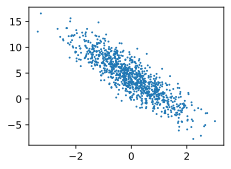

In [107]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(),
                labels.detach().numpy(),
                1)

In [108]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 1.4759, -0.5447],
        [ 0.1010, -0.2493],
        [ 1.4309,  1.2845],
        [-0.9006, -0.0477],
        [-0.9753, -0.8999],
        [-1.3323,  1.2130],
        [-0.4261,  0.0967],
        [ 0.3241, -0.0309],
        [-0.7107, -1.2492],
        [-1.0757, -1.3058]]) 
 tensor([[ 8.9955],
        [ 5.2441],
        [ 2.6877],
        [ 2.5552],
        [ 5.2911],
        [-2.5806],
        [ 3.0394],
        [ 4.9599],
        [ 7.0471],
        [ 6.4811]])


In [109]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [110]:
def linreg(X, w, b):
    """"""
    return torch.matmul(X, w) + b

定义损失函数

In [111]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

定义优化算法

In [112]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

训练

In [113]:
lr = 0.05
num_epochs = 50
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch{epoch+1}, loss{float(train_l.mean())}')

epoch1, loss0.0005324092344380915
epoch2, loss4.9933631089515984e-05
epoch3, loss5.006753417546861e-05
epoch4, loss4.995091148884967e-05
epoch5, loss4.987957436242141e-05
epoch6, loss5.0180518883280456e-05
epoch7, loss4.988399086869322e-05
epoch8, loss5.060075272922404e-05
epoch9, loss5.005857383366674e-05
epoch10, loss4.999807424610481e-05
epoch11, loss4.998508302378468e-05
epoch12, loss4.996834468329325e-05
epoch13, loss4.993326365365647e-05
epoch14, loss4.99584166391287e-05
epoch15, loss4.991553578292951e-05
epoch16, loss5.054641223978251e-05
epoch17, loss5.030332613387145e-05
epoch18, loss5.00037131132558e-05
epoch19, loss5.000840610591695e-05
epoch20, loss4.992073809262365e-05
epoch21, loss5.0151698815170676e-05
epoch22, loss4.9945712817134336e-05
epoch23, loss5.0011061830446124e-05
epoch24, loss4.9878701247507706e-05
epoch25, loss4.992023605154827e-05
epoch26, loss4.9969545216299593e-05
epoch27, loss4.995620111003518e-05
epoch28, loss4.9933478294406086e-05
epoch29, loss5.00067399

In [114]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2

features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [115]:
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个pytorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

next(iter(data_iter))

# for i,j in iter(data_iter):
#     print(i)
#     print(j)

[tensor([[-0.7602, -1.1894],
         [ 1.4261,  0.2664],
         [-1.9424,  0.8018],
         [-0.1853, -0.8789],
         [-0.0580,  0.6521],
         [-0.8896, -0.7147],
         [ 0.4952, -0.5565],
         [ 1.5268,  0.8023],
         [-0.4027, -0.1058],
         [-3.1857,  0.4573]]),
 tensor([[ 6.7354],
         [ 6.1519],
         [-2.3925],
         [ 6.8082],
         [ 1.8726],
         [ 4.8554],
         [ 7.0686],
         [ 4.5266],
         [ 3.7598],
         [-3.7233]])]

定义模型

In [116]:
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

初始化模型参数

In [117]:
net

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
)

In [118]:
net[0].weight.data.normal_(0, 0.01)

tensor([[0.0184, 0.0105]])

In [119]:
net[0].bias.data.fill_(0)

tensor([0.])

In [120]:
loss = nn.MSELoss()

In [121]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

训练

In [122]:
num_epochs = 10
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y) # 求梯度
        trainer.zero_grad() # 将模型的梯度清零
        l.backward() # 求模型参数相对于损失的梯度
        trainer.step() # 更新模型参数
    l = loss(net(features), labels)
    print(f'epoch{epoch + 1}, loss{1:f}')

epoch1, loss1.000000
epoch2, loss1.000000
epoch3, loss1.000000
epoch4, loss1.000000
epoch5, loss1.000000
epoch6, loss1.000000
epoch7, loss1.000000
epoch8, loss1.000000
epoch9, loss1.000000
epoch10, loss1.000000
